# Домашнее задание 2. Работа с изображениями

В этом задании предлагается решить простейшую задачу рапознавания лиц. Вам нужно будет научить модель для пары картинок определять, разные ли люди на них изображены.

Работать будем с датасетом фотографий известных людей. Скачать его можно [тут](https://disk.360.yandex.ru/d/oAmJgPESjP33hg). В нём представлены 150 человек, для каждого по 6-9 фотографий. Всего около 1000 изображений.

__Задание__. Вам потребуется выполнить два задания:

1) Реализовать модель бинарной классификации и добиться приемлемого качества.

2) Реализовать триплетную функцию потерь и улучшить качество предсказаний с ее помощью.

Напишите краткий отчёт о проделанных экспериментах. Что сработало и что не сработало? Почему вы решили, сделать так, а не иначе? Обязательно указывайте ссылки на чужой код, если вы его используете. Обязательно ссылайтесь на статьи / блогпосты / вопросы на stackoverflow / видосы от ютуберов-машинлернеров / курсы / подсказки от Дяди Васи и прочие дополнительные материалы, если вы их используете.

__Во всех заданиях будем придерживаться следующих правил__:
1. Использовать внешние данные для обучения строго запрещено. Также запрещено обучаться на валидационной выборке.
2. Все задания должны быть выполнены без использования предобученных моделей и готовых реализаций. Тем не менее:
    - В заданиях, где требуется достичь некоторого качества модели, разрешается использовать предобученные модели. Но __оценка за задние будет снижена__ (для каждого задания будет отдельно указано, на сколько).
    - В некоторых заданиях может сильно помочь библотека [pytorch-metric-learning](https://kevinmusgrave.github.io/pytorch-metric-learning/). Вы можете использовать готовые реализации из неё, но __максимальный балл за задание также будет снижен__.

__Советы и указания__:
 - Наверняка вам потребуется много гуглить о том, как заставить это всё работать. Это нормально, все гуглят. Но не забывайте, что нужно быть готовым за скатанный код отвечать :)
 - Рекомендуем использовать шаблоны ниже. Однако делать это мы не заставляем. Если вам так неудобно, то можете писать код в удобном стиле. Однако учтите, что чрезмерное изменение нижеперечисленных шаблонов увеличит количество вопросов к вашему коду :)
 - Валидируйте. Трекайте ошибки как можно раньше, чтобы не тратить время впустую.
 - Чтобы быстро отладить код, пробуйте обучаться на маленькой части датасета (скажем, 5-10 картинок просто чтобы убедиться что код запускается). Когда вы поняли, что смогли всё отдебажить, переходите обучению по всему датасету
 - На каждый запуск делайте ровно одно изменение в модели/аугментации/оптимайзере, чтобы понять, что и как влияет на результат.
 - Фиксируйте random seed.
 - Правильно нормализуйте данные при создании, пример [тык, но тут и в целом гайд от и до](https://www.pluralsight.com/guides/image-classification-with-pytorch)
 - Начинайте с простых моделей и постепенно переходите к сложным. Обучение лёгких моделей экономит много времени. Можно написать свою модель руками, а можно импортировать не предобученную сетку известной архитектуры из модуля `torchvision.models`. Один из способов как можно сделать: [документация (полезная)](https://pytorch.org/vision/stable/models.html)
 - Используйте все возможные методы оптимизации и эксперемнтируйте с ними.
 - Ставьте расписание на learning rate. Уменьшайте его, когда лосс на валидации перестаёт убывать.
 - Model Checkpointing. Сохраняйте свой прогресс (модели), чтобы когда что-то пойдет не так вы сможете начать с этого места или просто воспроизвести свои результаты модели, которые обучали.
    * Пример как можно с wandb тут: [Сохраняем лучшие модели в wandb](https://docs.wandb.ai/guides/integrations/lightning)
    * По простому можно так: [Сохраняем модели в pytorch дока](https://pytorch.org/tutorials/beginner/saving_loading_models.html)
 - Советуем использовать GPU. Если у вас его нет, используйте google colab. Если вам неудобно его использовать на постоянной основе, напишите и отладьте весь код локально на CPU, а затем запустите уже написанный ноутбук в колабе.

Good luck & have fun! :)

In [1]:
import os
import tqdm
import numpy as np

import torch
import pandas as pd
import random
import torchvision
import sklearn.metrics
import torch.utils.data
import matplotlib.pyplot as plt
import torchvision.transforms.v2
import torch.nn as nn
import torch.optim as optim

In [2]:
# Обязательно вызывайте эту функцию перед каждый запуском обучения!
# Если проверяющий не сможет воспроизвести результат, оценка за задание будет снижена.
def set_random_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### [1.5 балла] Часть 1. Подготовка данных.

##### [0.5 балла] Задание 1.1. Считать датасет.

Сначала нужно считать датасет с фотографиями и посмотреть на его устройство.

In [3]:
from google.colab import files
uploaded = files.upload()
import zipfile
import os
zip_file_path = 'data.zip'
os.makedirs('data', exist_ok=True)
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall('data')

Saving data.zip to data (1).zip


In [5]:
from torchvision import transforms as T
transform =T.Compose([
    T.Resize((128,128)),
    T.ToTensor(),
    T.Normalize((0.1307,), (0.3081,)),
]) ### YOUR CODE HERE ###

train_ds = torchvision.datasets.ImageFolder("/content/data/data/training", transform = transform)
test_ds = torchvision.datasets.ImageFolder("/content/data/data/testing", transform = transform)

Давайте посмотрим на примеры фотографий. Нарисуйте несколько.

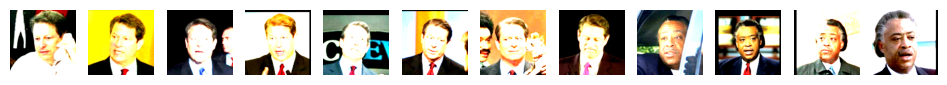

In [6]:
plt.figure(figsize=(15, 5))
for i in range(12):
    img, label = train_ds[i]
    img = img.permute(1, 2, 0)
    plt.subplot(2, 15, i + 1)
    plt.imshow(img)
    plt.axis('off')
plt.show()

Наконец, следует вывести распределение фотографий по людям и убедиться, что для каждого человека действительно предствалено 6-9 фотографий.

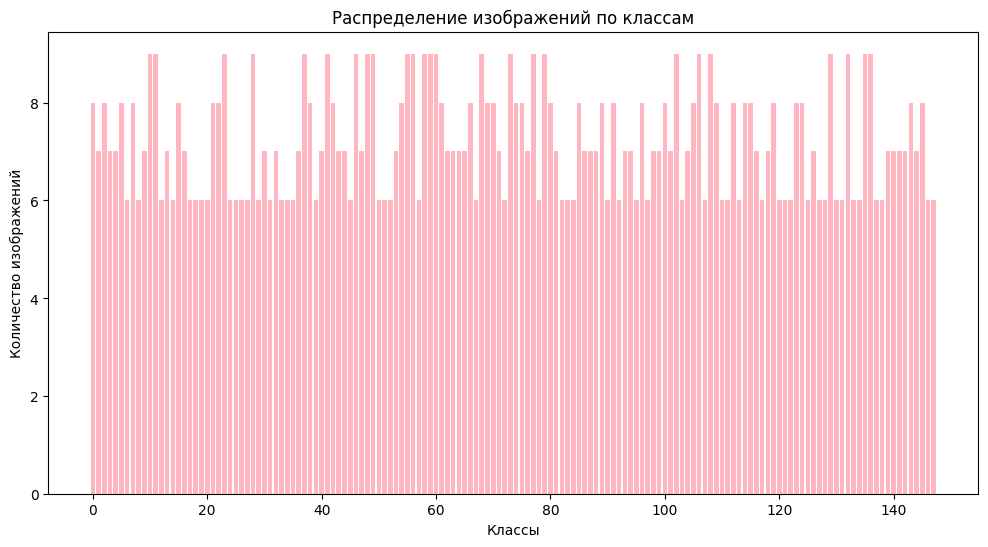

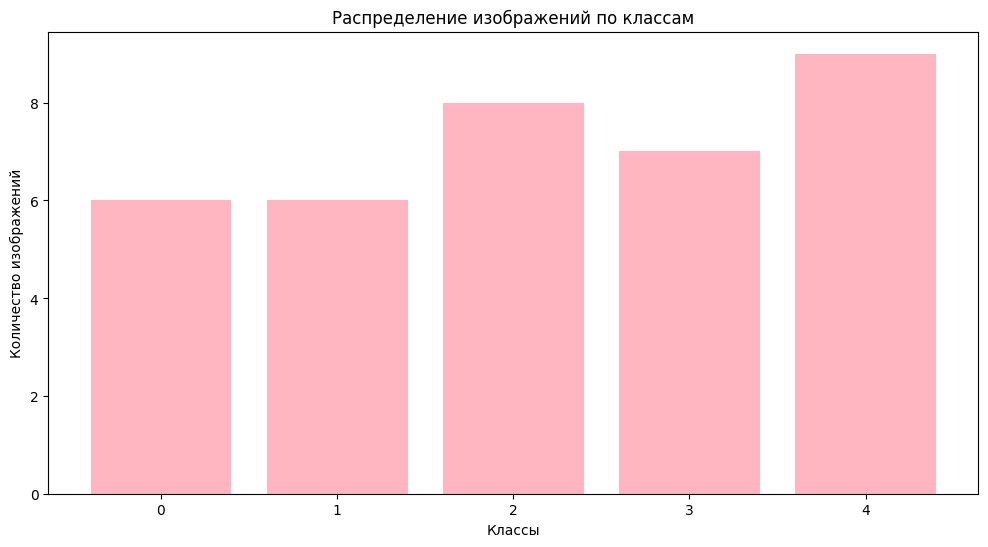

In [7]:
from collections import Counter
def show_class_distribution(targets):
    if isinstance(targets,torch.Tensor):
      targets=targets.cpu().numpy().tolist()
    class_counts = Counter(targets)
    classes = list(class_counts.keys())
    counts = list(class_counts.values())

    plt.figure(figsize=(12, 6))
    plt.bar(classes, counts, color='lightpink')
    plt.xlabel('Классы')
    plt.ylabel('Количество изображений')
    plt.title('Распределение изображений по классам')
    plt.show()

show_class_distribution(train_ds.targets)
show_class_distribution(test_ds.targets)

##### [0 баллов] Задание 1.2. Датасет пар.

Как было сказано ранее, мы будем обучать модели предсказывать, разные ли люди изображены на фотографиях. Для этого нам надо научиться формировать пары фотографий и целевую переменную из двух классов: 0 и 1. \
Класс 0 означает, что это фотографии одного человека. \
Класс 1 означает фотографии разных людей. \
 \
К счастью, весь датасет уже написан.

In [8]:
class PairDataset(torch.utils.data.Dataset):
    def __init__(self, dataset):
        self.dataset = dataset
        self.targets = [ self._get_target(i) for i in tqdm.trange(len(self)) ]

    def _idx1(self, idx):
        return idx % len(self.dataset)

    def _idx2(self, idx):
        return idx // len(self.dataset)

    def _get_target(self, idx):
        return int(self.dataset.targets[self._idx1(idx)] != self.dataset.targets[self._idx2(idx)])

    def __len__(self):
        return len(self.dataset) ** 2

    def __getitem__(self, idx):
        image1, label1 = self.dataset[self._idx1(idx)]
        image2, label2 = self.dataset[self._idx2(idx)]
        return image1, image2, int(label1 != label2)

train_pairs = PairDataset(train_ds)
test_pairs = PairDataset(test_ds)


100%|██████████| 1296/1296 [00:00<00:00, 968261.13it/s]


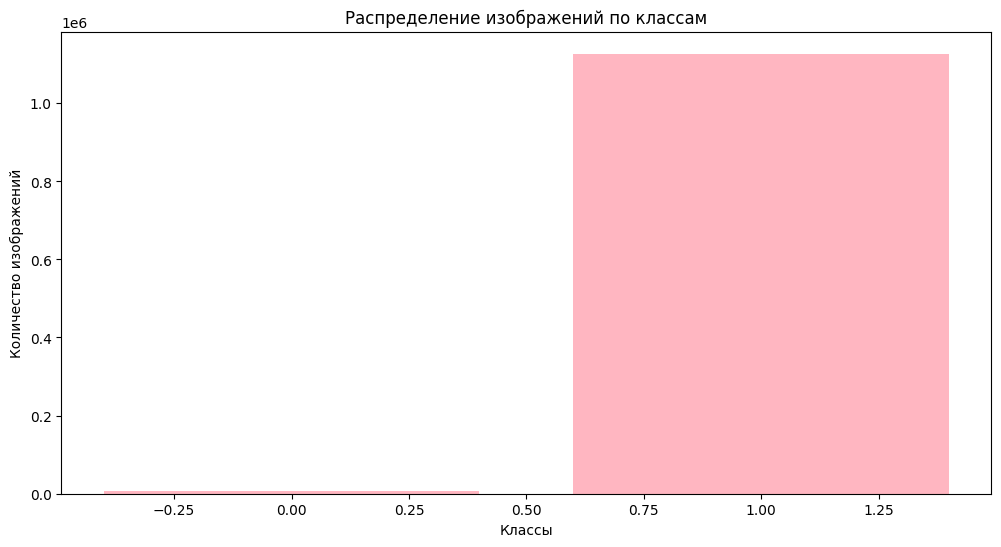

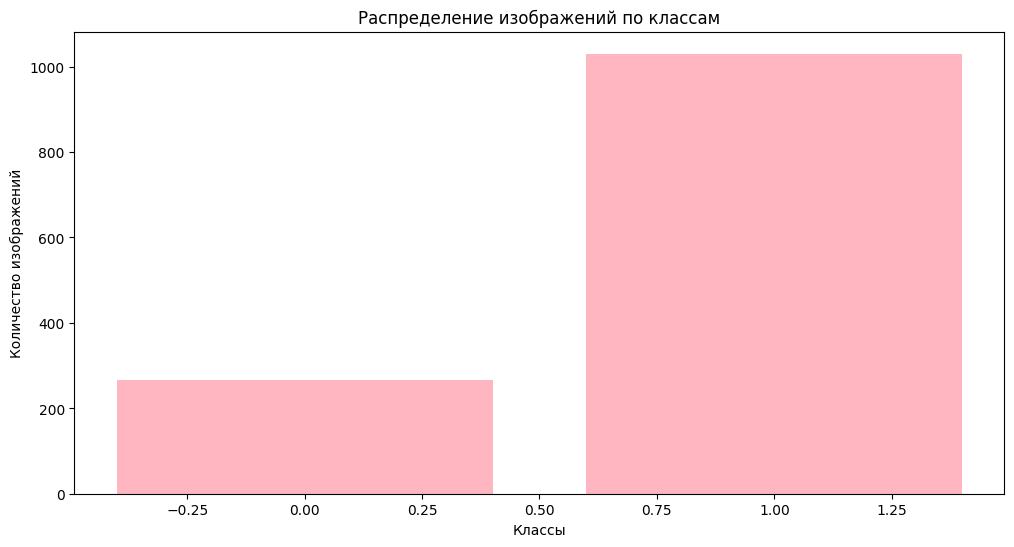

In [9]:
show_class_distribution(train_pairs.targets)
show_class_distribution(test_pairs.targets)

Легко видеть, что пар фотографий разных людей гораздо больше, чем пар фотографий одного человека. Это вполне ожидаемо, но, если не предпринять мер, ведет к двум проблемам:
1. Метрика качества предсказаний должна учитывать дисбаланс классов. В частности, accuracy нам не подойдёт. А использовать будем известный из курса машинного обучения AUC-ROC.
2. Нужно "подтюнить" даталоадер тренировочных данных, чтобы в каждый батч попадало примерно одинаковое количество фотографий каждого класса. Иначе победить деградацию модели к "всегда 1" будет очень сложно.

##### [1 балл] Задание 1.3. Стратифицированный даталоадер.

Для начала решим вторую проблему. Нужно сделать такой даталоадер, чтобы в каждом батче количество элементов класса "0" совпадало с количеством элементов класса "1".

Как известно, стандартный класс `DataLoader` в torch имеет много параметров. В частности, параметр `sampler` позволяет гибко управлять выдачей. Изучите [документацию](https://docs.pytorch.org/docs/stable/data.html#data-loading-order-and-sampler) и реализуйте свой семплер, который решит проблему.

В `pytorch_metric_learning` уже есть готовая реализация того, что нам нужно. Вы можете её найти и использовать. Но в таком случае __максимальный балл за это задание - 0.4__.

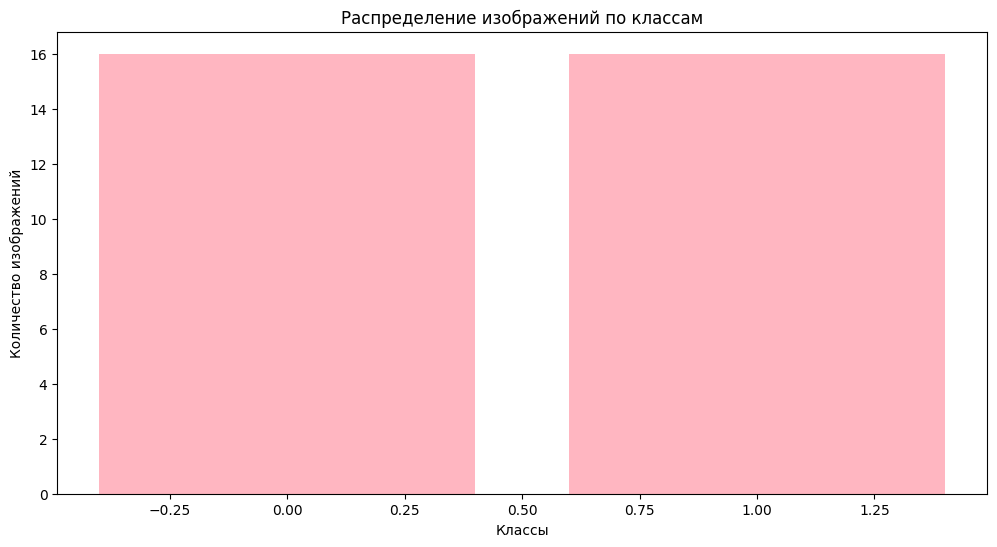

In [10]:
import torch
from torch.utils.data import Sampler
import numpy as np

class BalancedSampler(Sampler):
    def __init__(self, targets, batch_size):
        assert batch_size % 2 == 0
        self.targets = targets
        self.batch_size = batch_size
        self.class_indices = {0: [], 1: []}

        for idx, target in enumerate(targets):
            self.class_indices[target].append(idx)

        np.random.shuffle(self.class_indices[0])
        np.random.shuffle(self.class_indices[1])

        self.num_batches = min(len(self.class_indices[0]), len(self.class_indices[1])) // (batch_size // 2)

    def __iter__(self):
        indices_0 = self.class_indices[0].copy()
        indices_1 = self.class_indices[1].copy()

        np.random.shuffle(indices_0)
        np.random.shuffle(indices_1)

        all_indices = []
        for i in range(self.num_batches):
            start_idx = i * (self.batch_size // 2)
            end_idx = start_idx + (self.batch_size // 2)

            batch_indices = indices_0[start_idx:end_idx] + indices_1[start_idx:end_idx]
            all_indices.extend(batch_indices)

        return iter(all_indices)

    def __len__(self):
        return self.num_batches * self.batch_size

train_pairs_sampler = BalancedSampler(train_pairs.targets, batch_size=32)
train_pairs_loader = torch.utils.data.DataLoader(train_pairs, batch_size=32, sampler=train_pairs_sampler)
test_pairs_loader = torch.utils.data.DataLoader(test_pairs, batch_size=64, shuffle=False)

# Убедимся, что теперь выдача равномерная.
show_class_distribution(next(iter(train_pairs_loader))[2])


### [3.5 балла] Часть 2. Классификация.

Начнём с простого: попробуем решить проблему как обычную задачу бинарной классификации. Реализуйте и обучите обычную свёрточную сеть, которая принимает два набора фотографий и предсказывает вероятность, что это фотографии разных людей.

##### [1 балл] Задание 2.1. Модель классификации.

Сначала нужно реализовать модель. В `forward` необходимо принять два батча фотографий. `i`-e число в выводе `forward` должно быть предсказанием для пары из `i`-й фотографии `image1` и `i`-й фотографии `image2`. Подумайте, как это сделать. Возможно, стоит как-нибудь склеить `image1` и `image2`? Или склеить эмбеддинги? А может быть нужен какой-то трешхолд?

Вы вольны использовать любую архитектуру сети. Ассерт в конце ячейки поможет вам убедиться, что модель теоретически делает то, что нужно.

In [12]:
import torch
import torch.nn as nn

class ClassificationNet(nn.Module):
    def __init__(self):
        super(ClassificationNet, self).__init__()

        self.squeezer = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(512),
            nn.MaxPool2d(kernel_size=2),
        )

        self.embedding = nn.Sequential(
            nn.Linear(512 * 4 * 4, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, 256)
        )

        self.comparison = nn.Sequential(
            nn.Linear(256 * 2, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, image1, image2):
        embed1 = self.embedding(self.squeezer(image1).view(image1.size(0), -1))
        embed2 = self.embedding(self.squeezer(image2).view(image2.size(0), -1))
        combo = torch.cat([embed1, embed2], dim=1)

        return self.comparison(combo).squeeze()

# Вы можете использовать этот ассерт в качестве теста.
assert ClassificationNet()(*next(iter(train_pairs_loader))[:2]).shape == (32,)


##### [2 балла] Задание 2.2. Обучение.

Теперь обучите свою модель и добейтесь приемлемого качества. Балл за это задание вычисляется по формуле:

$$ clamp(0, 2.5 \cdot \dfrac{AucRoc - 0.6}{0.2}, 2.5) $$

То есть, для получения полного балла за это задание необходимо добиться AUC-ROC `0.8`

__При использовани предобученных моделей, балл за это задание умножается на 0.5__ (то есть, не более 1)

In [31]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ClassificationNet().to(device)
print(f"Using device: {device}")


Using device: cuda


In [32]:
def get_score(auc_roc):
    return max(0, min(2.5 * (auc_roc - 0.6) / 0.2, 2.5))

def get_auc_roc(your_model):
    preds = []
    targets = []
    your_model.eval()
    for images1, images2, labels in tqdm.tqdm(test_pairs_loader):
        with torch.no_grad():
            output = your_model(images1.to(device), images2.to(device))
        preds.extend(output.detach().cpu().tolist())
        targets.extend(labels.detach().cpu().tolist())
    preds = np.array(preds)
    targets = np.array(targets)
    return sklearn.metrics.roc_auc_score(targets, preds)

In [36]:

model = ClassificationNet().to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.00001)

for epoch in range(9):
    model.train()
    for images1, images2, labels in tqdm.tqdm(train_pairs_loader):
        images1, images2, labels = images1.to(device), images2.to(device), labels.float().to(device)
        optimizer.zero_grad()
        outputs = model(images1, images2)
        loss = criterion(outputs.squeeze(), labels)
        loss.backward()
        optimizer.step()

    print(f'Epoch [{epoch+1}/{5}], Loss: {loss.item():.4f}')

100%|██████████| 490/490 [00:59<00:00,  8.26it/s]


Epoch [1/5], Loss: 0.6949


100%|██████████| 490/490 [00:59<00:00,  8.29it/s]


Epoch [2/5], Loss: 0.7145


100%|██████████| 490/490 [00:59<00:00,  8.24it/s]


...

Epoch [7/5], Loss: 0.4715


100%|██████████| 490/490 [00:59<00:00,  8.24it/s]


Epoch [8/5], Loss: 0.3752


100%|██████████| 490/490 [00:59<00:00,  8.26it/s]

Epoch [9/5], Loss: 0.3761


In [37]:
c=get_auc_roc(model)

100%|██████████| 21/21 [00:04<00:00,  4.32it/s]


In [38]:
c

np.float64(0.8661252646178552)

In [39]:
get_score(c)

2.5

##### [0.5 балла] Задание 2.3. Анализ и отчет.

Опишите свои эксперименты. Проанализируйте результаты. Почему результаты получились не очень хорошими? Может быть, решать задачу через бинарную классификацию - не лучшая идея? Приведите не менее 3 аргументов, почему это так.

### [5 баллов] Часть 3. Распознавание лиц.

Теперь попробуем использовать более хитрые методы, которые лучше подходят для решаемой задачи. В частности, триплетную функцию потерь. Далее наша модель будет не предсказывать вероятность для двух картинок, а формировать эмбеддинги для одной картинки таким образом, чтобы эмбеддинги фотографий одного человека были близки, а разных людей - далеки.

##### [2 балла] Задание 3.1. Триплетная функция потерь.

Напомним теорию. Пусть $A$ - произвольное изображение; $P$ - изображение того же человека (позитивный пример); $N$ - изображение любого другого человека (негативный пример); $f$ - наша нейронная сеть; $\alpha$ - гиперпараметр, отвечающий за желаемый “отступ” – расстояние между латентными представлениями изображений разных людей. Тогда функционал ошибки определяется следующим образом:

$$ L(A, P, N) = max(||f(A) - f(P)|| - ||f(A) - f(N)|| + \alpha, 0) $$

В этом задании вам необходимо реализовать этот функционал. Для удобства в дальнейшем, предлагается сразу реализовать batch-версию. Таким образом, на входе должно быть 2 параметра:
- Набор эмбеддингов размера (batch_size, embedding_size)
- Набор классов (номера людей, чьи это фотографии) размера (batch_size)

Ваша функция должна найти все тройки $(A, P, N)$ и вычислить лосс для них.

В `pytorch_metric_learning` уже есть готовая реализация. Вы можете её найти и использовать. Но в таком случае __максимальный балл за это задание - 0.5__.

In [55]:
class FastTripletLoss(nn.Module):
    def __init__(self, margin=0.2):
        super(FastTripletLoss, self).__init__()
        self.margin = margin

    def forward(self, embeddings, labels):
        n = embeddings.size(0)
        dist_matrix = torch.cdist(embeddings, embeddings, p=2)
        labels_expanded = labels.unsqueeze(1)
        same_class_mask = (labels_expanded == labels_expanded.t())
        diff_class_mask = (labels_expanded != labels_expanded.t())
        eye_mask = torch.eye(n, device=embeddings.device).bool()
        same_class_mask = same_class_mask & ~eye_mask

        pos_distances = dist_matrix.masked_fill(~same_class_mask, -1)
        hardest_pos_dist, _ = pos_distances.max(dim=1)
        neg_distances = dist_matrix.masked_fill(~diff_class_mask, float('inf'))
        hardest_neg_dist, _ = neg_distances.min(dim=1)
        valid_mask = (hardest_pos_dist != -1) & (hardest_neg_dist != float('inf'))

        if valid_mask.sum() == 0:
            # ИСПРАВЛЕНИЕ: возвращаем тензор с градиентами
            return torch.tensor(0.0, device=embeddings.device, requires_grad=True)

        losses = torch.clamp(
            hardest_pos_dist[valid_mask] - hardest_neg_dist[valid_mask] + self.margin, min=0.0)

        return losses.mean()

In [56]:
criterion=FastTripletLoss() # Вы можете использовать этот ассерт в качестве теста
embeddings = torch.tensor([
    [ 1., 2, 3 ],
    [ 1, 3, 4 ],
    [ 4, 5, 6 ]
])
labels = torch.tensor([ 1., 2, 1 ])
assert (criterion(embeddings, labels) - 2.6775) < 1e-4

##### [3 балла] Задание 3.2. Обучение.

Теперь обучите модель и добейтесь приемлемого качества. Балл за это задание вычисляется по формуле:

$$ clamp(0, 3 \cdot \dfrac{AucRoc - 0.8}{0.15}, 3) $$

То есть, для получения полного балла за это задание необходимо добиться AUC-ROC `0.95`

При необходимости, вы можете улучшить функцию потерь. Например, учитывать не все тройки, а только "сложные", как это умеет делать реализация в `pytorch_metric_learning`. Также подумайте над даталоадером. Возможно, имеет смысл брать в батч одинаковое количество фотографий каждого человека по аналгии с заданием 1.3? Тем не менее имейте в виду, что для получения полного балла за задание, вы должны реализовать все модификации самостоятельно, а не использовать готовые.

__При использовани предобученных моделей, балл за это задание умножается на 0.5__ (то есть, не более 1.5) \
__При использовани pytorch_metric_learning, балл за это задание уменьшается на 0.5 за каждое использование__

In [93]:
class EmbeddingNet(nn.Module):
    def init__(self):  # ИСПРАВЛЕНО: __init
        super(EmbeddingNet, self).__init__()  # ИСПРАВЛЕНО: init

        self.squeezer = nn.Sequential(
            # Block 1: 128x128 -> 64x64
            nn.Conv2d(3, 32, 3, stride=2, padding=1),  # ВОССТАНОВЛЕНО: stride=2
            nn.BatchNorm2d(32),  # ДОБАВЛЕНО
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 64x64 -> 32x32

            # Block 2: 32x32 -> 16x16
            nn.Conv2d(32, 64, 3, stride=2, padding=1),  # ВОССТАНОВЛЕНО: stride=2
            nn.BatchNorm2d(64),  # ДОБАВЛЕНО
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 16x16 -> 8x8

            # Block 3: 8x8 -> 4x4
            nn.Conv2d(64, 128, 3, stride=2, padding=1),  # ВОССТАНОВЛЕНО: stride=2
            nn.BatchNorm2d(128),  # ДОБАВЛЕНО
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 4x4 -> 2x2

            # Block 4: 2x2 -> 1x1
            nn.Conv2d(128, 256, 3, stride=1, padding=1),
            nn.BatchNorm2d(256),  # ДОБАВЛЕНО
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1))  # Всегда дает 256x1x1
        )

        # Теперь размер всегда 256
        self.embedding = nn.Sequential(
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),  # ДОБАВЛЕНО
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
        )

    def forward(self, x):
        x = self.squeezer(x)
        x = x.view(x.size(0), -1)  # (batch_size, 256)
        x = self.embedding(x)
        return F.normalize(x, p=2, dim=1)  # ДОБАВЛЕНО: нормализация

In [84]:
transform =T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
]) ### YOUR CODE HERE ###

train_ds = torchvision.datasets.ImageFolder("/content/data/data/training", transform = transform)
test_ds = torchvision.datasets.ImageFolder("/content/data/data/testing", transform = transform)

In [90]:
import torch.nn.functional as F
class ImprovedEmbeddingNet(nn.Module):
    def __init__(self, embedding_dim=128):
        super(ImprovedEmbeddingNet, self).__init__()  # Исправлено: init

        # Улучшенный backbone с residual connections и batch norm
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )

        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )

        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 256, 3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((4, 4))  # Универсальный pooling
        )

        # Авторасчет размера
        with torch.no_grad():
            x = torch.randn(1, 3, 128, 128)
            output_size = self.forward_features(x).view(1, -1).size(1)
            print(f"Embedding input size: {output_size}")

        # Улучшенный embedding слой
        self.embedding = nn.Sequential(
            nn.Linear(output_size, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),

            nn.Linear(256, embedding_dim),
        )



    def forward_features(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        return x

    def forward(self, x):
        x = self.forward_features(x)
        x = x.view(x.size(0), -1)
        x = self.embedding(x)
        # Критически важная нормализация для Triplet Loss
        return F.normalize(x, p=2, dim=1)


In [86]:
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=32, shuffle=True)

In [96]:
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=32, shuffle=True)
set_random_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EmbeddingNet().to(device)
criterion = FastTripletLoss(margin=0.25)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
for epoch in range(25):
    model.train()
    for images, labels in tqdm.tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)
        pred = model(images)
        loss = criterion(pred, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}")

ValueError: optimizer got an empty parameter list

In [88]:
def get_score(auc_roc):
    return max(0, min(3 * (auc_roc - 0.8) / 0.15, 3))

def get_auc_roc(your_model):
    preds = []
    targets = []
    your_model.eval()
    for images1, images2, labels in tqdm.tqdm(test_pairs_loader):
        with torch.no_grad():
            emb1, emb2 = your_model(images1.to(device)),your_model(images2.to(device))
            # Вы можете изменить функцию расстояния между эмбеддингами, если считаете нужным
            dist = ((emb1 - emb2) ** 2).sum(dim = 1)
        preds.extend(dist.detach().cpu().tolist())
        targets.extend(labels.detach().cpu().tolist())
    preds = np.array(preds)
    targets = np.array(targets)
    return sklearn.metrics.roc_auc_score(targets, preds)

print(get_auc_roc(model))

100%|██████████| 21/21 [00:05<00:00,  3.85it/s]

0.6736696109205051


##### [0.1 балла] Бонус: распознай себя

В качестве бонуса, загрузите свою фотографию (можно не одну), пропустите ее через модель и определите, на кого из известных людей, по мнению модели, вы больше всего похоже.

In [ ]:
### YOUR CODE HERE ###